# Paquetes

In [1]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import os
import sys
from PIL import Image
from multiprocessing import Process, Pool, Manager
import pickle 

from keras import metrics
from keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv3D, MaxPooling3D, Reshape

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, accuracy_score
from qiskit.quantum_info import SparsePauliOp
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.patches as mpatches
import seaborn as sns

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2024-07-10 10:47:52.055321: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-10 10:47:52.960276: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Num GPUs Available:  8


In [2]:
# os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'
# os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

# Carga de Datos

## Train

In [3]:
root_dir = "datos_im/train/"

patient_codes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
patients_data = []

labels_tr=[]

array_shape = (32, 32)

for patient_code in patient_codes:
    patient_dir = os.path.join(root_dir, patient_code)
    paciente=patient_dir.split("/")[2]
    clase = paciente.split('_')[0]
    
    patient_images_rad = []
    patient_images_circ = []
    
    image_files = sorted([f for f in os.listdir(patient_dir) if os.path.isfile(os.path.join(patient_dir, f)) and f.lower().endswith('.png')])
    
    for image_file in image_files:
        image_path = os.path.join(patient_dir, image_file)
        image = Image.open(image_path).convert('L')
        image = image.resize(array_shape)

        if image_path.split('_')[-1].split('.')[0]=="radial":
            patient_images_rad.append(image)
        elif image_path.split('_')[-1].split('.')[0]=="circunf":
            patient_images_circ.append(image)
    
    patients_data.append((patient_images_rad,patient_images_circ))
    labels_tr.append((paciente, clase))

max_num_images = max(len(images) for images in patients_data)

num_patients = len(patients_data)
train_radial = np.zeros((num_patients, 16, array_shape[0], array_shape[1]), dtype=np.uint8)
train_circunf = np.zeros((num_patients, 16, array_shape[0], array_shape[1]), dtype=np.uint8)

for i, patient_images in enumerate(patients_data):
    for j, image in enumerate(patient_images[0]):
        train_radial[i, j, :, :] = image
    for j, image in enumerate(patient_images[1]):
        train_circunf[i, j, :, :] = image

In [4]:
train_imgs_tf_rad = (train_radial / 255)*np.pi
train_imgs_tf_circ = (train_circunf / 255)*np.pi

df_tr = pd.DataFrame(labels_tr, columns=['patient', 'class'])

In [5]:
print(train_imgs_tf_rad.shape)
print(train_imgs_tf_circ.shape)

print(df_tr.shape)

print(df_tr.head())

(116, 16, 32, 32)
(116, 16, 32, 32)
(116, 2)
    patient class
0  C_A2N8V0     C
1  C_A3B7E5     C
2  C_A3H1O5     C
3  C_A4U9V5     C
4  C_A5Q1W8     C


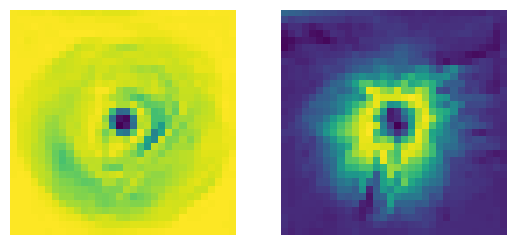

In [6]:
fig,ax=plt.subplots(1,2)
ax[0].imshow(train_imgs_tf_rad[0,0,:,:])
ax[0].axis('off')

ax[1].imshow(train_imgs_tf_circ[0,0,:,:])
ax[1].axis('off')
plt.show()

## Validation

In [7]:
root_dir = "datos_im/validation/"

patient_codes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
patients_data = []

labels_val=[]

array_shape = (32, 32)

for patient_code in patient_codes:
    patient_dir = os.path.join(root_dir, patient_code)
    paciente=patient_dir.split("/")[2]
    clase = paciente.split('_')[0]
    
    patient_images_rad = []
    patient_images_circ = []
    
    image_files = sorted([f for f in os.listdir(patient_dir) if os.path.isfile(os.path.join(patient_dir, f)) and f.lower().endswith('.png')])
    
    for image_file in image_files:
        image_path = os.path.join(patient_dir, image_file)
        image = Image.open(image_path).convert('L')
        image = image.resize(array_shape)

        if image_path.split('_')[-1].split('.')[0]=="radial":
            patient_images_rad.append(image)
        elif image_path.split('_')[-1].split('.')[0]=="circunf":
            patient_images_circ.append(image)
    
    patients_data.append((patient_images_rad,patient_images_circ))
    labels_val.append((paciente, clase))

max_num_images = max(len(images) for images in patients_data)

num_patients = len(patients_data)
val_radial = np.zeros((num_patients, 16, array_shape[0], array_shape[1]), dtype=np.uint8)
val_circunf = np.zeros((num_patients, 16, array_shape[0], array_shape[1]), dtype=np.uint8)

for i, patient_images in enumerate(patients_data):
    for j, image in enumerate(patient_images[0]):
        val_radial[i, j, :, :] = image
    for j, image in enumerate(patient_images[1]):
        val_circunf[i, j, :, :] = image

In [8]:
val_imgs_tf_rad = (val_radial / 255)*np.pi
val_imgs_tf_circ = (val_circunf / 255)*np.pi

df_val = pd.DataFrame(labels_val, columns=['patient', 'class'])

In [9]:
print(val_imgs_tf_rad.shape)
print(val_imgs_tf_circ.shape)

print(df_val.shape)

print(df_val.head())

(13, 16, 32, 32)
(13, 16, 32, 32)
(13, 2)
    patient class
0  C_C5M4S2     C
1  C_D0H9I4     C
2  C_D1S5T8     C
3  C_E9H1U4     C
4  C_K2S1U6     C


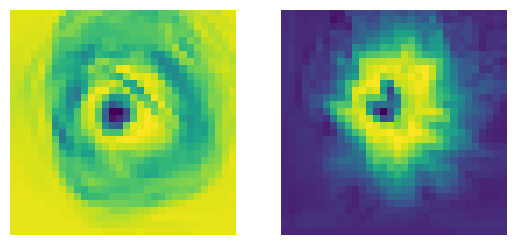

In [10]:
fig,ax=plt.subplots(1,2)
ax[0].imshow(val_imgs_tf_rad[0,0,:,:])
ax[0].axis('off')

ax[1].imshow(val_imgs_tf_circ[0,0,:,:])
ax[1].axis('off')
plt.show()

## Test

In [11]:
root_dir = "datos_im/test/"

patient_codes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
patients_data = []

labels_test=[]

array_shape = (32, 32)

for patient_code in patient_codes:
    patient_dir = os.path.join(root_dir, patient_code)
    paciente=patient_dir.split("/")[2]
    clase = paciente.split('_')[0]
    
    patient_images_rad = []
    patient_images_circ = []
    
    image_files = sorted([f for f in os.listdir(patient_dir) if os.path.isfile(os.path.join(patient_dir, f)) and f.lower().endswith('.png')])
    
    for image_file in image_files:
        image_path = os.path.join(patient_dir, image_file)
        image = Image.open(image_path).convert('L')
        image = image.resize(array_shape)

        if image_path.split('_')[-1].split('.')[0]=="radial":
            patient_images_rad.append(image)
        elif image_path.split('_')[-1].split('.')[0]=="circunf":
            patient_images_circ.append(image)
    
    patients_data.append((patient_images_rad,patient_images_circ))
    labels_test.append((paciente, clase))

max_num_images = max(len(images) for images in patients_data)

num_patients = len(patients_data)
test_radial = np.zeros((num_patients, 16, array_shape[0], array_shape[1]), dtype=np.uint8)
test_circunf = np.zeros((num_patients, 16, array_shape[0], array_shape[1]), dtype=np.uint8)

for i, patient_images in enumerate(patients_data):
    for j, image in enumerate(patient_images[0]):
        test_radial[i, j, :, :] = image
    for j, image in enumerate(patient_images[1]):
        test_circunf[i, j, :, :] = image

In [12]:
test_imgs_tf_rad = (test_radial / 255)*np.pi
test_imgs_tf_circ = (test_circunf / 255)*np.pi

df_test = pd.DataFrame(labels_test, columns=['patient', 'class'])

In [13]:
print(test_imgs_tf_rad.shape)
print(test_imgs_tf_circ.shape)

print(df_test.shape)

print(df_test.head())

(17, 16, 32, 32)
(17, 16, 32, 32)
(17, 2)
    patient class
0  C_B2F4K5     C
1  C_C4R8T7     C
2  C_D6H6O2     C
3  C_G1J5K3     C
4  C_G4L8Z7     C


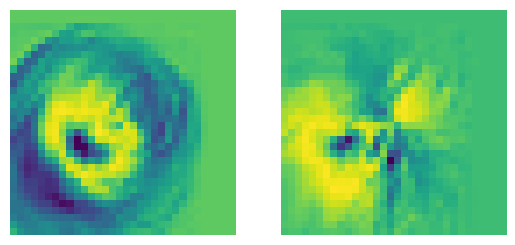

In [14]:
fig,ax=plt.subplots(1,2)
ax[0].imshow(test_imgs_tf_rad[0,0,:,:])
ax[0].axis('off')

ax[1].imshow(test_imgs_tf_circ[0,0,:,:])
ax[1].axis('off')
plt.show()

## Estadísticas de los datos

In [15]:
def plot_class_distribution(labels, dataset_name):
    unique_classes, counts = np.unique(labels, return_counts=True)
    plt.bar(unique_classes, counts)
    plt.title(f'Class Distribution in {dataset_name} Set')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()


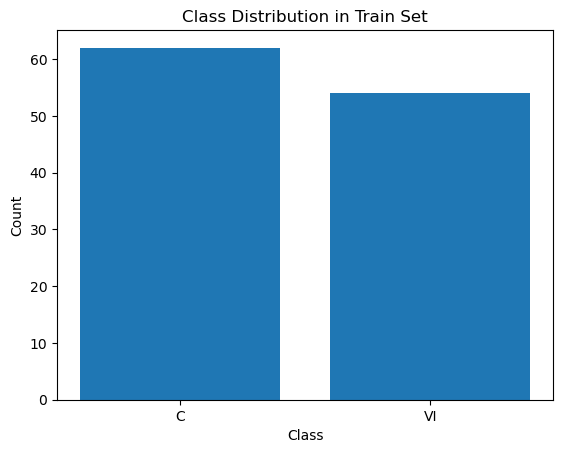

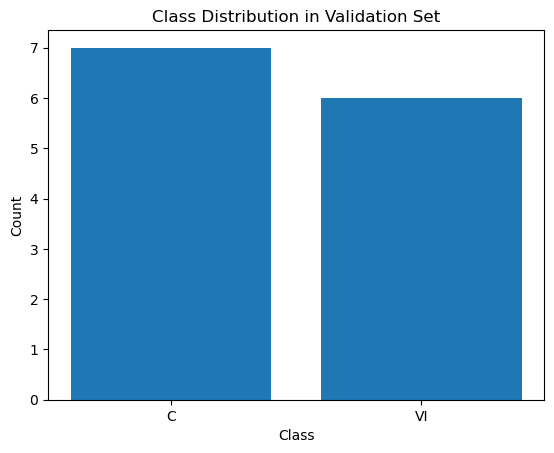

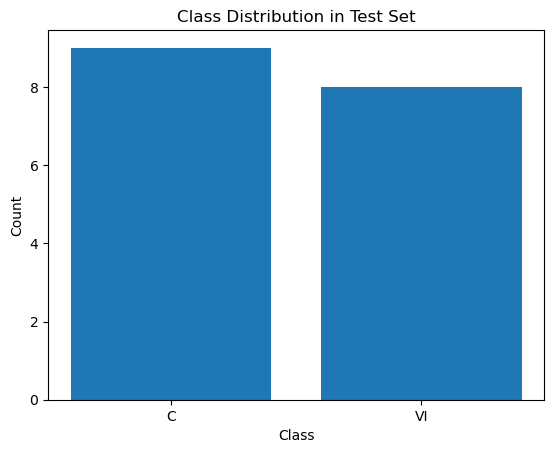

In [16]:
plot_class_distribution(df_tr["class"], 'Train')
plot_class_distribution(df_val["class"], 'Validation')
plot_class_distribution(df_test["class"], 'Test')

# Circuitos Cuánticos

In [17]:
n_qubits = 8
graphs = {
    "king" : [[0,1],[0,2],[0,3],[0,4],[0,5],[0,6],[0,7],[1,2],[1,3],[1,4],[1,5],[1,6],[1,7],[2,3],[2,4],[2,5],[2,6],[2,7],[3,4],[3,5],[3,6],[3,7],[4,5],[4,6],[4,7],[5,6],[5,7],[6,7]],
    "closed-nn" : [[0,1], [1,3], [3,2], [2,0], [0,4], [1,5], [2,6], [3,7], [4,5], [5,7], [7,6], [6,4]],
    "open-nn": [[0,1],[1,2],[2,3],[3,4],[4,5],[5,6],[6,7]],
    "gamma" : [[0,5],[0,3],[0,6],[1,4],[1,7],[1,2],[2,7],[2,4],[3,6],[3,5],[4,7],[5,6]]
}

dev = qml.device('default.qubit', wires=n_qubits)

## King

In [18]:
@qml.qnode(dev, interface="autograd")
def king_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["king"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

## Closed

In [19]:
@qml.qnode(dev, interface="autograd")
def closed_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["closed-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

## Opened

In [20]:
@qml.qnode(dev, interface="autograd")
def open_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["open-nn"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

## Gamma

In [21]:
@qml.qnode(dev, interface="autograd")
def gamma_circuit(params):
    """creates a quantum kernel based on a digital-analog quantum encoding.

    Args:
        params (torch.Parameters): trainable parameters

    Returns:
        list: expectation values of <Z> on each qubit
    """
    
    # DIGITAL ENCODING OF THE PIXELS
    for idx in range(n_qubits):
        qml.RY(params[idx], wires=idx)
        qml.Hadamard(wires=idx)
        
    # RYDBERG HAMILTONIAN EVOLUTION
    for t in [0.05, 0.1]:
        for qubit in range(n_qubits):
            qml.RX(t, wires=qubit)
            qml.RZ(t/2, wires=qubit)
        for pair in graphs["gamma"]:
            qml.CNOT(wires=[pair[0], pair[1]])
            qml.RZ(phi=np.pi/3, wires=pair[1])
            qml.CNOT(wires=[pair[0], pair[1]])
    
    # DIGITAL SINGLE-QUBIT OPERATIONS
    for qubit in range(n_qubits):
        qml.RY(np.pi/2, wires=qubit) 
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Quanvolución

In [22]:
array_shape1=(16,32,32)
def quanv(idx, image, folder, type):
    """Convolves the input image with many applications of the same quantum circuit."""
    out = np.zeros((array_shape1[0]-1, array_shape1[1]-1, array_shape1[2]-1,32))

    # Loop over the coordinates of the top-left pixel of 2X2 squares
    for j in range(0, array_shape1[0]-1, 1):
        for k in range(0, array_shape1[1]-1, 1):
            for l in range(0, array_shape1[2]-1, 1):
                a0=image[j, k, l]
                a1=image[j, k + 1, l]
                a2=image[j, k, l + 1]
                a3=image[j, k + 1, l + 1]
                
                b0=image[j + 1, k, l]
                b1=image[j + 1, k + 1, l]
                b2=image[j + 1, k, l + 1]
                b3=image[j + 1, k + 1, l + 1]
    
                q1_results = king_circuit( # circuit 2
                    [
                        a0,
                        a1,
                        a2,
                        a3,
                        b0,
                        b1,
                        b2,
                        b3
                    ]
                )
                q2_results = closed_circuit( # circuit 2
                    [
                        a0,
                        a1,
                        a2,
                        a3,
                        b0,
                        b1,
                        b2,
                        b3
                    ]
                )
                q3_results = open_circuit( # circuit 3
                    [
                        a0,
                        a1,
                        a2,
                        a3,
                        b0,
                        b1,
                        b2,
                        b3
                    ]
                )
                q4_results = gamma_circuit( # circuit 3
                    [
                        a0,
                        a1,
                        a2,
                        a3,
                        b0,
                        b1,
                        b2,
                        b3
                    ]
                )
    
                for c in range(8): 
                    out[j, k, l, c] = q1_results[c]
                for c in range(8):
                    out[j, k, l, c+8] = q2_results[c]
                for c in range(8): 
                    out[j, k, l, c+16] = q3_results[c]
                for c in range(8):
                    out[j, k, l, c+24] = q4_results[c]
    if type=="rad":
        if folder=="train":
            with open(f"quantum_rad/train/train_{idx}.pkl", "wb") as file:
                pickle.dump(out, file)
        elif folder=="validation":
            with open(f"quantum_rad/validation/val_{idx}.pkl", "wb") as file:
                pickle.dump(out, file)
        elif folder=="test":
            with open(f"quantum_rad/test/test_{idx}.pkl", "wb") as file:
                pickle.dump(out, file)
    if type=="circ":
        if folder=="train":
            with open(f"quantum_circ/train/train_{idx}.pkl", "wb") as file:
                pickle.dump(out, file)
        elif folder=="validation":
            with open(f"quantum_circ/validation/val_{idx}.pkl", "wb") as file:
                pickle.dump(out, file)
        elif folder=="test":
            with open(f"quantum_circ/test/test_{idx}.pkl", "wb") as file:
                pickle.dump(out, file)

## Radial

In [23]:
if __name__=="__main__":
    num_cores = os.cpu_count() - 2
    
    pool_tr = Pool(processes=num_cores)
    pool_val = Pool(processes=num_cores)
    pool_test = Pool(processes=num_cores)
    
    # PROCCESS TRAIN DATA SET
    print("Quantum pre-processing of train images")
    for idx, img in enumerate(train_imgs_tf_rad):
        pool_tr.apply_async(quanv, args=(idx,img,"train","rad"))
    pool_tr.close()
    pool_tr.join()

    # PROCCESS VALIDATION DATA SET
    print("Quantum pre-processing of validation images")
    for idx, img in enumerate(val_imgs_tf_rad):
        pool_val.apply_async(quanv, args=(idx,img,"validation","rad"))
    pool_val.close()
    pool_val.join()
    
    # PROCCESS TEST DATA SET
    print("Quantum pre-processing of test images")
    for idx, img in enumerate(test_imgs_tf_rad):
        pool_test.apply_async(quanv, args=(idx,img,"test","rad"))
    pool_test.close()
    pool_test.join()

Quantum pre-processing of train images
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
Quantum pre-processing of validation images
Quantum pre-processing of test images


In [23]:
def load_data_to_cpu(file_pattern, num_files):
    data_list = []
    for idx in range(num_files):
        with open(file_pattern.format(idx), "rb") as file:
            data = pickle.load(file)
        data_list.append(data)
    data_array = np.asarray(data_list)
    return data_array

In [24]:
def cpu_to_gpu(X):
    X_tensor = tf.convert_to_tensor(X)
    
    return tf.identity(X_tensor)

In [25]:
q_train_images_rad = load_data_to_cpu("quantum_rad/train/train_{}.pkl", len(train_imgs_tf_rad))
print(q_train_images_rad.shape)

q_val_images_rad = load_data_to_cpu("quantum_rad/validation/val_{}.pkl", len(val_imgs_tf_rad))
print(q_val_images_rad.shape)

q_test_images_rad = load_data_to_cpu("quantum_rad/test/test_{}.pkl", len(test_imgs_tf_rad))
print(q_test_images_rad.shape)

q_train_images_gpu_rad = cpu_to_gpu(q_train_images_rad)
print(q_train_images_gpu_rad.shape)

q_val_images_gpu_rad = cpu_to_gpu(q_val_images_rad)
print(q_val_images_gpu_rad.shape)

q_test_images_gpu_rad = cpu_to_gpu(q_test_images_rad)
print(q_test_images_gpu_rad.shape)

train_imgs_tf_rad_gpu=cpu_to_gpu(train_imgs_tf_rad)
val_imgs_tf_rad_gpu=cpu_to_gpu(val_imgs_tf_rad)
test_imgs_tf_rad_gpu=cpu_to_gpu(test_imgs_tf_rad)

(116, 15, 31, 31, 32)
(13, 15, 31, 31, 32)
(17, 15, 31, 31, 32)
(116, 15, 31, 31, 32)
(13, 15, 31, 31, 32)
(17, 15, 31, 31, 32)


2024-07-10 10:48:04.674301: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1212 MB memory:  -> device: 0, name: NVIDIA A16, pci bus id: 0000:85:00.0, compute capability: 8.6
2024-07-10 10:48:04.683493: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 9693 MB memory:  -> device: 1, name: NVIDIA A16, pci bus id: 0000:86:00.0, compute capability: 8.6
2024-07-10 10:48:04.689593: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 13163 MB memory:  -> device: 2, name: NVIDIA A16, pci bus id: 0000:87:00.0, compute capability: 8.6
2024-07-10 10:48:04.701911: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 13163 MB memory:  -> device: 3, name: NVIDIA A16, pci bus id: 0000:88:00.0, compute capability: 8.6
20

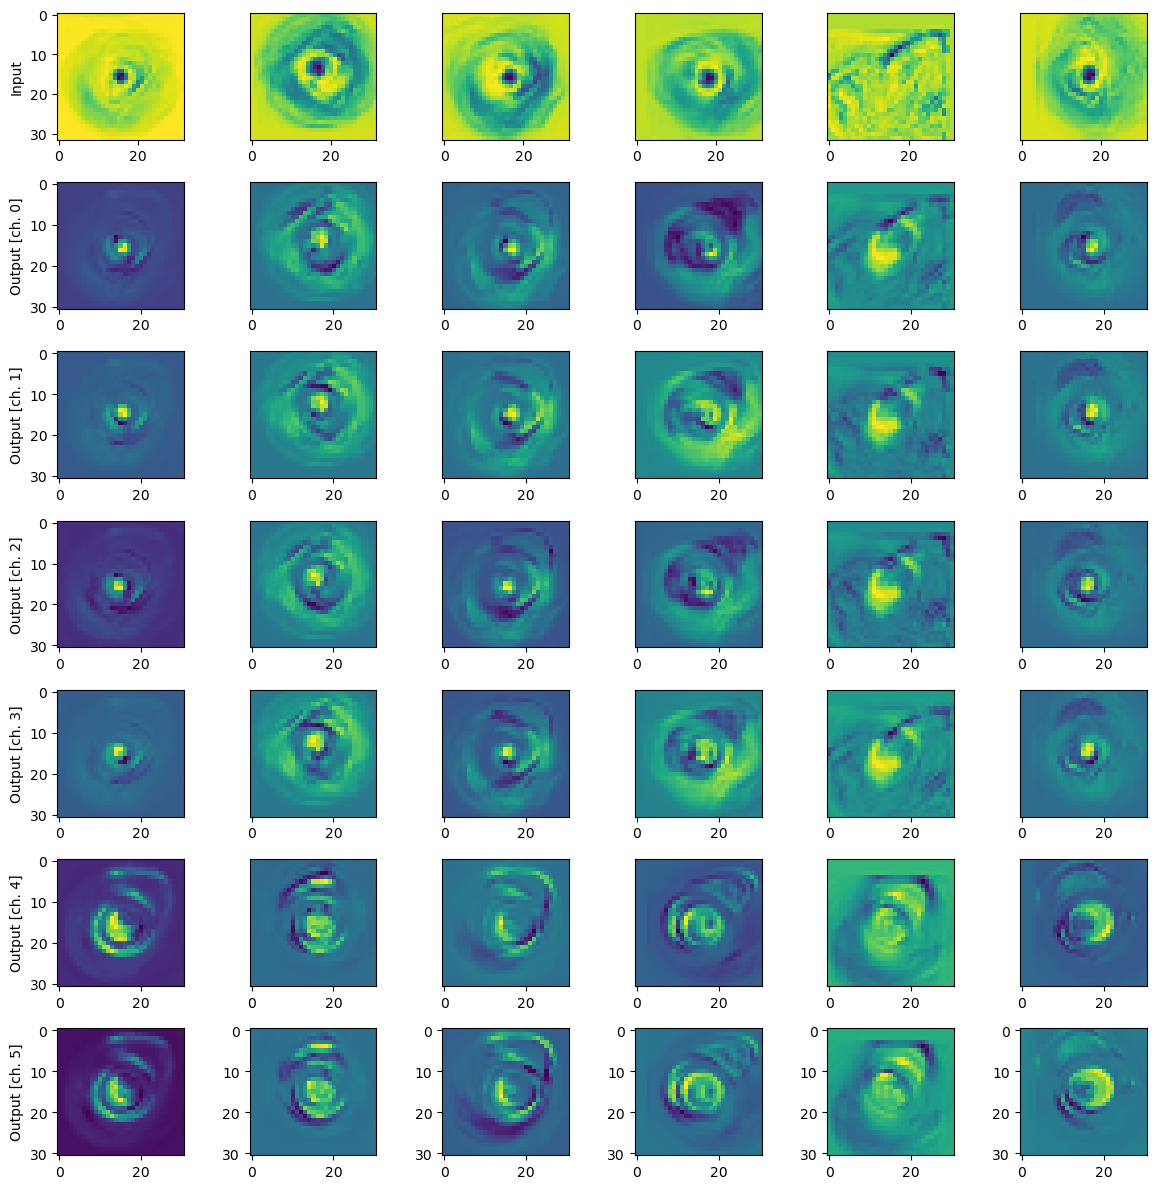

In [26]:
# PRINT SOME SAMPLES
n_samples = 6
n_channels = 6
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(12, 12))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_imgs_tf_rad[k, 0, :, :])

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images_rad[k, 0, : ,: , c])

plt.tight_layout()
plt.show()

# Modelos básicos

In [27]:
def cnn(learning_rate, activation, dropout):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Conv3D(32, 2, strides = 1, activation='relu', input_shape=(array_shape1[0],array_shape1[1],array_shape1[2],1)), #Convolucion que sustituye a la cuantica
        keras.layers.Reshape((15, 31, 31, 32)),
        keras.layers.Conv3D(32, 2, strides = 1, activation=activation, padding="same"),
        keras.layers.BatchNormalization(momentum=0.96),
        keras.layers.MaxPooling3D(pool_size=3),
        keras.layers.Conv3D(32, 2, strides = 1, activation=activation, trainable=True, padding="same"),
        keras.layers.Dropout(dropout),
        keras.layers.Flatten(),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return model

def qcnn(learning_rate, activation, dropout):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Conv3D(32, 2, strides = 1, activation=activation, input_shape=(array_shape1[0]-1,array_shape1[1]-1,array_shape1[2]-1,32), padding="same"),
        keras.layers.BatchNormalization(momentum=0.96),
        keras.layers.MaxPooling3D(pool_size=3),
        keras.layers.Conv3D(32, 2, strides = 1, activation=activation, padding="same"),
        keras.layers.Dropout(dropout),
        keras.layers.Flatten(),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["binary_accuracy"],
    )
    return model

In [28]:
# Verifica las dimensiones de las imágenes de entrenamiento
print(f'q_train_images_rad shape: {q_train_images_rad.shape}')
print(f'q_val_images_rad shape: {q_val_images_rad.shape}')
print(f'train_imgs_tf_rad shape: {train_imgs_tf_rad.shape}')
print(f'val_imgs_tf_rad shape: {val_imgs_tf_rad.shape}')

q_train_images_rad shape: (116, 15, 31, 31, 32)
q_val_images_rad shape: (13, 15, 31, 31, 32)
train_imgs_tf_rad shape: (116, 16, 32, 32)
val_imgs_tf_rad shape: (13, 16, 32, 32)


In [29]:
train_imgs_tf_rad=train_imgs_tf_rad.reshape((116,16,32,32,1))
val_imgs_tf_rad=val_imgs_tf_rad.reshape((13,16,32,32,1))

In [30]:
print(f'train_imgs_tf_rad shape: {train_imgs_tf_rad.shape}')
print(f'val_imgs_tf_rad shape: {val_imgs_tf_rad.shape}')

train_imgs_tf_rad shape: (116, 16, 32, 32, 1)
val_imgs_tf_rad shape: (13, 16, 32, 32, 1)


In [31]:
Encoder=LabelEncoder()

train_labels=Encoder.fit_transform(df_tr["class"].values)
val_labels=Encoder.fit_transform(df_val["class"].values)
test_labels=Encoder.fit_transform(df_test["class"].values)

## QCNN

In [38]:
q_model = qcnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)

q_model.summary()

/home/maloto3/anaconda3/envs/quantum/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 15, 31, 31, 32) │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15, 31, 31, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 5, 10, 10, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 5, 10, 10, 32)  │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 10, 10, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        16,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,577 (127.25 KB)

 Trainable params: 32,513 (127.00 KB)

 Non-trainable params: 64 (256.00 B)

In [39]:
q_history = q_model.fit(
    q_train_images_gpu_rad,
    train_labels,
    validation_data=(q_val_images_gpu_rad, val_labels),
    batch_size=8,
    epochs=200,
    verbose=2
)

Epoch 1/200


I0000 00:00:1720603968.715803 1071967 service.cc:145] XLA service 0x7fcff402cc40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1720603968.715857 1071967 service.cc:153]   StreamExecutor device (0): NVIDIA A16, Compute Capability 8.6
I0000 00:00:1720603968.715866 1071967 service.cc:153]   StreamExecutor device (1): NVIDIA A16, Compute Capability 8.6
I0000 00:00:1720603968.715870 1071967 service.cc:153]   StreamExecutor device (2): NVIDIA A16, Compute Capability 8.6
I0000 00:00:1720603968.715873 1071967 service.cc:153]   StreamExecutor device (3): NVIDIA A16, Compute Capability 8.6
I0000 00:00:1720603968.715880 1071967 service.cc:153]   StreamExecutor device (4): NVIDIA A16, Compute Capability 8.6
I0000 00:00:1720603968.715888 1071967 service.cc:153]   StreamExecutor device (5): NVIDIA A16, Compute Capability 8.6
I0000 00:00:1720603968.715893 1071967 service.cc:153]   StreamExecutor device (6): NVIDIA A16, Compute Capability 8.6
I0000

15/15 - 9s - 597ms/step - binary_accuracy: 0.5345 - loss: 1.6726 - val_binary_accuracy: 0.5385 - val_loss: 0.6712
Epoch 2/200
15/15 - 0s - 21ms/step - binary_accuracy: 0.6983 - loss: 0.7119 - val_binary_accuracy: 0.5385 - val_loss: 0.6668
Epoch 3/200
15/15 - 0s - 18ms/step - binary_accuracy: 0.7414 - loss: 0.6011 - val_binary_accuracy: 0.8462 - val_loss: 0.6379
Epoch 4/200
15/15 - 0s - 17ms/step - binary_accuracy: 0.8103 - loss: 0.4162 - val_binary_accuracy: 0.7692 - val_loss: 0.6151
Epoch 5/200
15/15 - 0s - 18ms/step - binary_accuracy: 0.8362 - loss: 0.3643 - val_binary_accuracy: 0.5385 - val_loss: 0.6199
Epoch 6/200
15/15 - 0s - 17ms/step - binary_accuracy: 0.9138 - loss: 0.2103 - val_binary_accuracy: 0.7692 - val_loss: 0.5619
Epoch 7/200
15/15 - 0s - 17ms/step - binary_accuracy: 0.9224 - loss: 0.1801 - val_binary_accuracy: 0.7692 - val_loss: 0.5072
Epoch 8/200
15/15 - 0s - 18ms/step - binary_accuracy: 0.9483 - loss: 0.1450 - val_binary_accuracy: 0.8462 - val_loss: 0.4803
Epoch 9/200

In [41]:
q_predictions=q_model.predict(q_test_images_gpu_rad)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 968ms/step


In [42]:
fprq, tprq, thresholdq = roc_curve(test_labels, q_predictions)

# AUC:
auc = roc_auc_score(test_labels, q_predictions)  

print("AUC:", auc)

# F1_score and recall:
f1 = f1_score(test_labels, np.round(q_predictions))

print('F1_Score:', f1)

# ACCURACY:
acc = accuracy_score(test_labels, np.round(q_predictions))
print('ACC:', acc)

AUC: 0.9722222222222222
F1_Score: 0.875
ACC: 0.8823529411764706


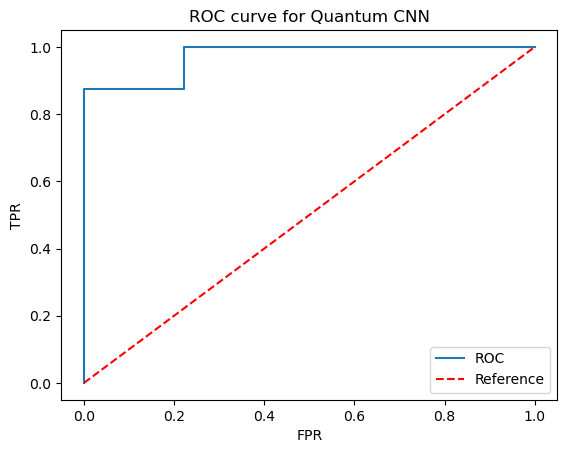

In [43]:
# Trazar la curva ROC
plt.plot(fprq, tprq, label='ROC')
plt.plot([0, 1], [0, 1], 'r--', label='Reference')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve for Quantum CNN')
plt.legend()
plt.show()

## CNN

In [44]:
c_model = cnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)

c_model.summary()

/home/maloto3/anaconda3/envs/quantum/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_2 (Conv3D)               │ (None, 15, 31, 31, 32) │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 15, 31, 31, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 15, 31, 31, 32) │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 31, 31, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 5, 10, 10, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_4 (Conv3D)               │ (None, 5, 10, 10, 32)  │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 10, 10, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,865 (128.38 KB)

 Trainable params: 32,801 (128.13 KB)

 Non-trainable params: 64 (256.00 B)

In [45]:
c_history = c_model.fit(
    cpu_to_gpu(train_imgs_tf_rad),
    train_labels,
    validation_data=(cpu_to_gpu(val_imgs_tf_rad), val_labels),
    batch_size=8,
    epochs=200,
    verbose=2,
)

Epoch 1/200
15/15 - 8s - 524ms/step - binary_accuracy: 0.4741 - loss: 1.0823 - val_binary_accuracy: 0.4615 - val_loss: 0.6896
Epoch 2/200
15/15 - 0s - 17ms/step - binary_accuracy: 0.5603 - loss: 0.6832 - val_binary_accuracy: 0.5385 - val_loss: 0.6822
Epoch 3/200
15/15 - 0s - 16ms/step - binary_accuracy: 0.7328 - loss: 0.5634 - val_binary_accuracy: 0.6154 - val_loss: 0.6771
Epoch 4/200
15/15 - 0s - 16ms/step - binary_accuracy: 0.7845 - loss: 0.4780 - val_binary_accuracy: 0.5385 - val_loss: 0.6626
Epoch 5/200
15/15 - 0s - 16ms/step - binary_accuracy: 0.7500 - loss: 0.4424 - val_binary_accuracy: 0.5385 - val_loss: 0.6288
Epoch 6/200
15/15 - 0s - 16ms/step - binary_accuracy: 0.8448 - loss: 0.3138 - val_binary_accuracy: 0.9231 - val_loss: 0.6080
Epoch 7/200
15/15 - 0s - 16ms/step - binary_accuracy: 0.8621 - loss: 0.3470 - val_binary_accuracy: 0.6923 - val_loss: 0.5206
Epoch 8/200
15/15 - 0s - 16ms/step - binary_accuracy: 0.8793 - loss: 0.2737 - val_binary_accuracy: 0.8462 - val_loss: 0.4948

In [47]:
c_predictions=c_model.predict(test_imgs_tf_rad)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step


In [48]:
fprq, tprq, thresholdq = roc_curve(test_labels, c_predictions)

# AUC:
auc = roc_auc_score(test_labels, c_predictions)  

print("AUC:", auc)

# F1_score and recall:
f1 = f1_score(test_labels, np.round(c_predictions))

print('F1_Score:', f1)

# ACCURACY:
acc = accuracy_score(test_labels, np.round(c_predictions))
print('ACC:', acc)

AUC: 0.9583333333333334
F1_Score: 0.875
ACC: 0.8823529411764706


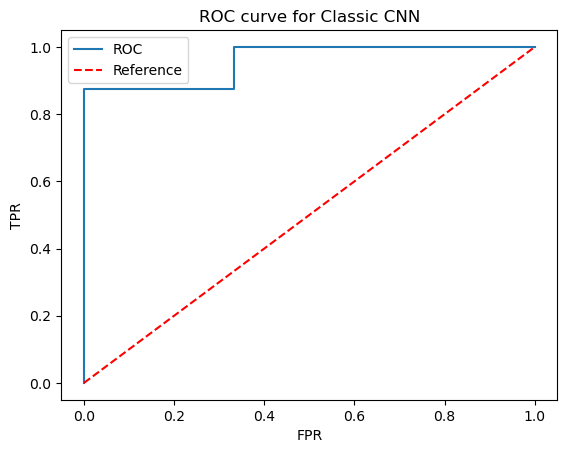

In [49]:

plt.plot(fprq, tprq, label='ROC')
plt.plot([0, 1], [0, 1], 'r--', label='Reference')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve for Classic CNN')
plt.legend()
plt.show()

# Robustez de los resultados

In [36]:
num_modelos= 30
classic_accuracies=[]
quantum_accuracies=[]

In [37]:
epochs=400

In [41]:
for _ in range(num_modelos):
    c_model  = cnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)
    
    c_history = c_model.fit(
    cpu_to_gpu(train_imgs_tf_rad),
    train_labels,
    validation_data=(cpu_to_gpu(val_imgs_tf_rad), val_labels),
    batch_size=16,
    epochs=epochs,
    verbose=0)

    classic_accuracies.append(c_history.history['val_binary_accuracy'])

2024-07-10 18:54:03.204178: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 204.51MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
I0000 00:00:1720637645.831440 1207215 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [42]:
for _ in range(num_modelos):
    q_model  = qcnn(learning_rate = 0.001, activation = 'relu', dropout = 0.5)
    
    q_history = q_model.fit(
    q_train_images_gpu_rad,
    train_labels,
    validation_data=(q_val_images_gpu_rad, val_labels),
    batch_size=16,
    epochs=epochs,
    verbose=0)

    quantum_accuracies.append(q_history.history['val_binary_accuracy'])

In [43]:
# Convert lists to numpy arrays for easier manipulation
q_accs = np.array(quantum_accuracies)
c_accs = np.array(classic_accuracies)

q_accs.shape
c_accs.shape 

(30, 400)

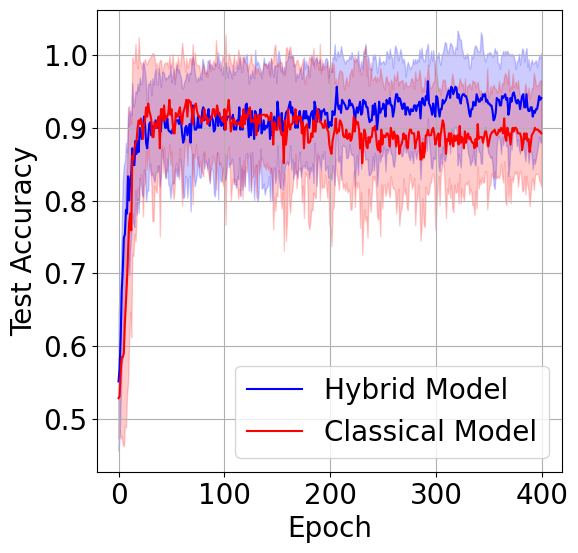

In [45]:
plt.rcParams.update({'font.size': 20})

# Calculate mean and standard deviation
q_mean = np.mean(q_accs, axis=0)
q_std = np.std(q_accs, axis=0)
c_mean = np.mean(c_accs, axis=0)
c_std = np.std(c_accs, axis=0)

# Plot the results
epochs = np.arange(400)
plt.figure(figsize=(6, 6))

# Quantum model plot
plt.plot(epochs, q_mean, label='Hybrid Model', color='blue')
plt.fill_between(epochs, q_mean - q_std, q_mean + q_std, color='blue', alpha=0.2)

# Classical model plot
plt.plot(epochs, c_mean, label='Classical Model', color='red')
plt.fill_between(epochs, c_mean - c_std, c_mean + c_std, color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()